# Baseline Model for Animals Dataset

For the baseline model for the animals dataset, we use a convolution neural network to classify animal images as real or fake (AI-generated). In order to create the baseline model, we prepared the data, built the CNN, and trained and evaluated it with the image data.

## Table of Contents
1. [Imports and Data Upload](#imports-and-data-upload)
2. [Data Preparation](#data-preparation)
3. [Model Building](#model-building)
4. [Model Training](#model-training)
5. [Model Evaluation](#model-evaluation)

### Imports and Data Upload

In [ ]:
import sys
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [ ]:
# unzip train dataset
zip_path = "dataset_train.zip"
extract_to = "data/animals/"
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path) as zf:
    for zip_info in zf.infolist():
        zip_info.filename = zip_info.filename.encode('cp437').decode('utf-8', errors='replace')
        zf.extract(zip_info, extract_to)

In [ ]:
# unzip test dataset
zip_path = "dataset_test.zip"
extract_to = "data/animals/"
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path) as zf:
    for zip_info in zf.infolist():
        zip_info.filename = zip_info.filename.encode('cp437').decode('utf-8', errors='replace')
        zf.extract(zip_info, extract_to)

### Data Preparation

To prepare the data, we create a tensorflow dataset from the images and scaled the pixel values to be between 0 and 1.

In [ ]:
def load_image_dataset(data_path, batch_size=32, img_size=(200, 200)):
    """
    load images into tensorflow dataset.

    parameters:
        data_path (str): dataset path.
        batch_size (int): number of images to use per batch.
        img_size (tuple): image size in pixels.

    returns:
        tf.data.Dataset object for training/testing with class names.
    """
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_path,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )

    class_names = dataset.class_names
    return dataset, class_names

In [9]:
def scale_image_dataset(dataset):
    """
    scales image dataset with helper function
    """
    def scale_img(image, label):
        """
        scales image pixel values to between [0, 1]
        """
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scale_img)

In [ ]:
# image parameters
BATCH_SIZE = 32
img_size = (200,200)
img_height, img_width = img_size

train_data_path = "dataset/animals/train"
test_data_path = "dataset/animals/test"

In [ ]:
# get datasets as tf datasets and scale pixel values
train_dataset, class_names = load_image_dataset(
    train_data_path, batch_size=BATCH_SIZE, img_size=img_size
)
train_dataset = scale_image_dataset(train_dataset)

test_dataset, _ = load_image_dataset(
    test_data_path, batch_size=BATCH_SIZE, img_size=img_size
)
test_dataset = scale_image_dataset(test_dataset)

train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Number of train batches: {train_count}")
print(f"Number of test batches: {test_count}\n")

print(f"Number of train images: {train_count * BATCH_SIZE}")
print(f"Number of test images: {test_count * BATCH_SIZE}")

print(f"Class names: {class_names}")

Found 119403 files belonging to 2 classes.


2025-04-27 18:17:36.798237: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3c:00.0, compute capability: 8.9


Found 29852 files belonging to 2 classes.
Number of train batches: 3732
Number of test batches: 933

Number of train images: 119424
Number of test images: 29856
Class names: ['fake', 'real']


### Model Building
To build the model, we used 2D convolutional layers with batch normalization and max pooling. We used relu activation for each convolutional layer. We then flattened the dimensions with a global average pooling layer. Finally, we use sigmoid activation for the output layer for 2 classes.

In [23]:
model_animals = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

In [24]:
model_animals.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_animals.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_13 (Conv2D)          (None, 200, 200, 32)      896       
                                                                 
 batch_normalization_13 (Ba  (None, 200, 200, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 100, 100, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_14 (Conv2D)          (None, 100, 100, 64)      18496     
                                                                 
 batch_normalization_14 (Ba  (None, 100, 100, 64)      256       
 tchNormalization)                                               
                                                      

### Model Training
We fit the model with the training dataset and use early stopping and a learning rate scheduler as our callback methods. 

In [25]:
epochs = 10

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)

history = model_animals.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/10
3732/3732 [==============================] - 165s 43ms/step - loss: 0.5659 - accuracy: 0.7107 - val_loss: 0.7852 - val_accuracy: 0.6075 - lr: 0.0010
Epoch 2/10
3732/3732 [==============================] - 163s 44ms/step - loss: 0.4863 - accuracy: 0.7500 - val_loss: 0.6414 - val_accuracy: 0.7074 - lr: 0.0010
Epoch 3/10
3732/3732 [==============================] - 163s 44ms/step - loss: 0.4432 - accuracy: 0.7713 - val_loss: 0.5133 - val_accuracy: 0.7311 - lr: 0.0010
Epoch 4/10
3732/3732 [==============================] - 164s 44ms/step - loss: 0.4088 - accuracy: 0.7891 - val_loss: 0.4213 - val_accuracy: 0.7904 - lr: 0.0010
Epoch 5/10
3732/3732 [==============================] - 163s 44ms/step - loss: 0.3821 - accuracy: 0.8055 - val_loss: 0.6600 - val_accuracy: 0.7042 - lr: 0.0010
Epoch 6/10
3732/3732 [==============================] - 163s 44ms/step - loss: 0.3609 - accuracy: 0.8195 - val_loss: 0.4207 - val_accuracy: 0.7860 - lr: 0.0010
Epoch 7/10
3732/3732 [==================

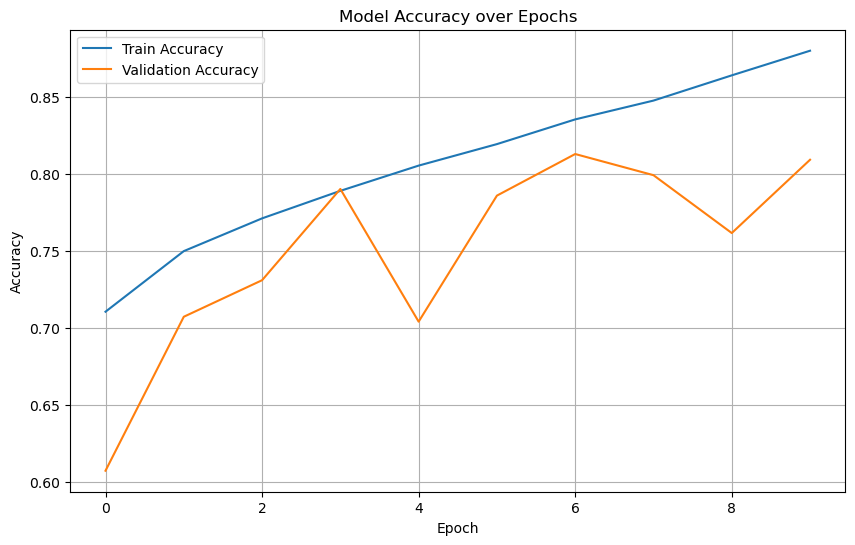

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

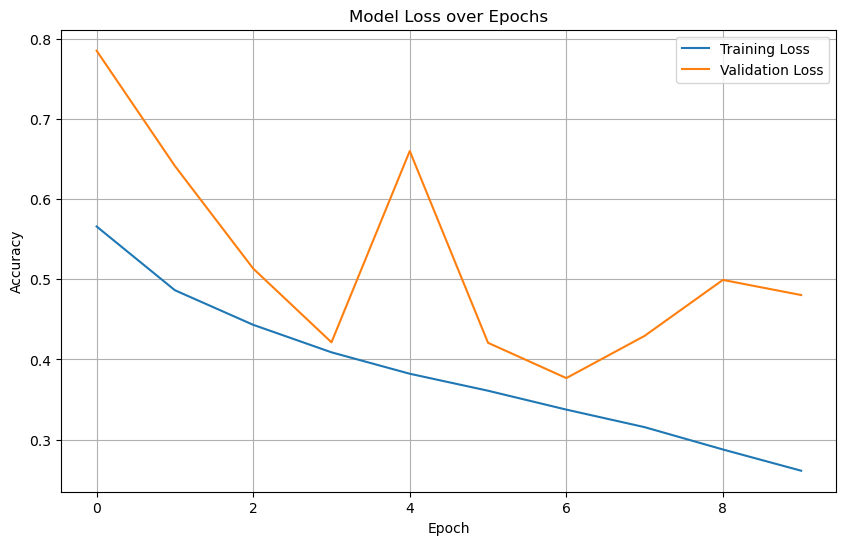

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The validation accuracy of the baseline model is approximately 80%. After 10 epochs, the validation loss and accuracy stop improving with the current architecture.

### Model Evaluation
Finally, we evaluated the model on the test dataset. We check the accuracy as well as the f1 score.

In [29]:
loss, accuracy = model_animals.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

933/933 [==============================] - 15s 15ms/step - loss: 0.3767 - accuracy: 0.8130
Test Loss: 0.3767, Test Accuracy: 0.8130


In [30]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred_probs = model_animals.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

933/933 [==============================] - 14s 14ms/step
Test Loss: 0.3767, Test Accuracy: 0.8130
Test F1 Score: 0.5798
Confusion Matrix:
[[5416 6849]
 [7612 9975]]

Classification Report:
              precision    recall  f1-score   support

        fake       0.42      0.44      0.43     12265
        real       0.59      0.57      0.58     17587

    accuracy                           0.52     29852
   macro avg       0.50      0.50      0.50     29852
weighted avg       0.52      0.52      0.52     29852

